In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import hdbscan
import umap

C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [2]:
# --- 1. DATA PREPARATION (Condensed for clarity) ---
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')

filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [(filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
              (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
              (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
df['Match_Outcomes'] = df['Game_ID'].map(dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes'])))

df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 
            'Away_Off_Sub_Count']
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# STAGE 1: BASELINE (The "Fragmented" Version)
# =================================================================
print("--- Stage 1: Baseline HDBSCAN (No Dimensionality Reduction) ---")
clusterer_base = hdbscan.HDBSCAN(min_cluster_size=20)
labels_base = clusterer_base.fit_predict(X_scaled)
print(f"Number of clusters found: {len(np.unique(labels_base))}")

--- Stage 1: Baseline HDBSCAN (No Dimensionality Reduction) ---
Number of clusters found: 1543



--- Stage 2: UMAP + HDBSCAN (Solving Fragmentation) ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


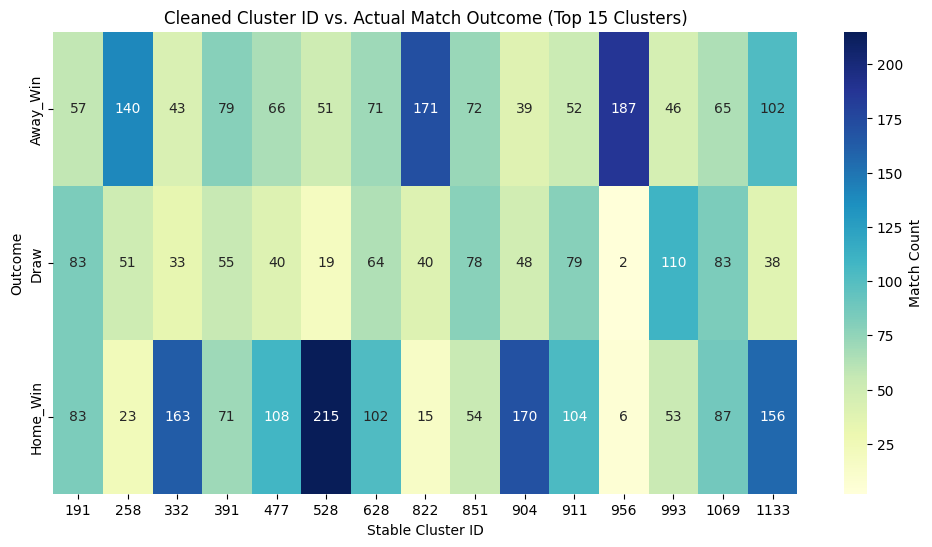


WHAT CHANGED:
1. UMAP Projection: Pre-processing with UMAP significantly thins the 'noise' between games.
2. min_cluster_size: Increased to 50 to prevent the fragmentation seen in your heatmap.
3. Visualization Filter: We now only show the top clusters, making the heatmap readable.


In [4]:
# STAGE 2: OPTIMIZED (UMAP + Parameters Fix)
# =================================================================
print("\n--- Stage 2: UMAP + HDBSCAN (Solving Fragmentation) ---")

# UMAP helps reduce dimensions while keeping "similar" games together
reducer = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# Tuning HDBSCAN to avoid the 900+ clusters seen in your image
clusterer_opt = hdbscan.HDBSCAN(
    min_cluster_size=50,       # Increased to force larger, more meaningful groups
    min_samples=10,            # High value reduces noise and prevents tiny clusters
    prediction_data=True,
    cluster_selection_method='eom' # 'eom' (Excess of Mass) is more stable than 'leaf'
)
labels_opt = clusterer_opt.fit_predict(X_umap)

# READABILITY FIX: Only plot top 15 largest clusters to avoid "stretching" the heatmap
unique_labels, counts = np.unique(labels_opt, return_counts=True)
# Filter out noise (-1) and keep only top 15 clusters
top_labels = unique_labels[np.argsort(counts)[-16:]]
top_labels = top_labels[top_labels != -1]

mask = np.isin(labels_opt, top_labels)
alignment = pd.crosstab(y_true[mask], labels_opt[mask])

plt.figure(figsize=(12, 6))
sns.heatmap(alignment, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Match Count'})
plt.title("Cleaned Cluster ID vs. Actual Match Outcome (Top 15 Clusters)")
plt.xlabel("Stable Cluster ID")
plt.ylabel("Outcome")
plt.show()

print("\nWHAT CHANGED:")
print("1. UMAP Projection: Pre-processing with UMAP significantly thins the 'noise' between games.")
print("2. min_cluster_size: Increased to 50 to prevent the fragmentation seen in your heatmap.")
print("3. Visualization Filter: We now only show the top clusters, making the heatmap readable.")


--- Stage 3: UMAP Spatial Analysis ---


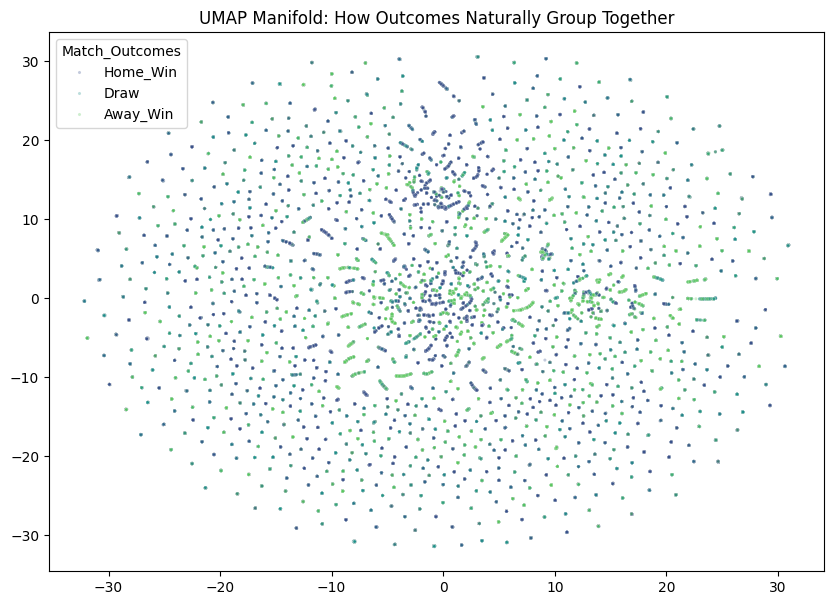

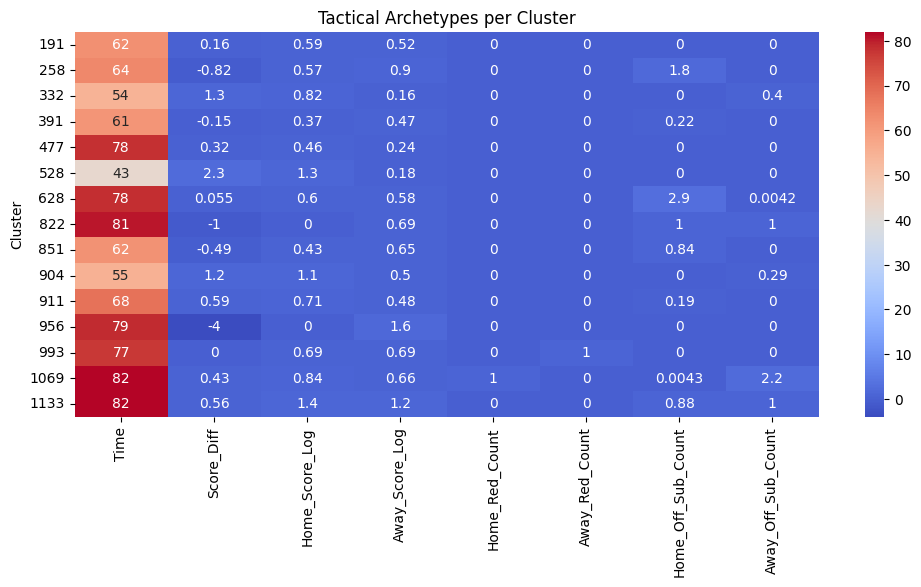

In [5]:
# STAGE 3: UMAP VISUALIZATION & FEATURE ANALYSIS
# =================================================================
print("\n--- Stage 3: UMAP Spatial Analysis ---")

plt.figure(figsize=(10, 7))
# Plotting the actual UMAP space colored by outcome
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_true, palette='viridis', s=5, alpha=0.3)
plt.title("UMAP Manifold: How Outcomes Naturally Group Together")
plt.show()

# Final Feature Archetypes
analysis_df = X.copy()
analysis_df['Cluster'] = labels_opt
cluster_means = analysis_df[analysis_df['Cluster'].isin(top_labels)].groupby('Cluster').mean()

plt.figure(figsize=(12, 5))
sns.heatmap(cluster_means.drop(columns=['Cluster'], errors='ignore'), annot=True, cmap='coolwarm')
plt.title("Tactical Archetypes per Cluster")
plt.show()